# Bài 2 — Dry Bean Dataset: Logistic Regression vs KNN

**Tuần 4 — Buổi 7: Phân loại 1 (Logistic Regression & KNN)**

Bộ dữ liệu **Dry Bean Dataset**: 13,611 hạt đậu thuộc 7 giống (Seker, Barbunya, Bombay, Cali, Dermason, Horoz, Sira),
mỗi hạt có 16 đặc trưng (area, perimeter, các trục, độ tròn, độ đặc, shape factors...).

Dữ liệu đã được tiền xử lý sẵn ở notebook `processing_seeds.ipynb` (đọc từ `Dry_Bean_Dataset.xlsx`, chuẩn hóa
tên cột, ép kiểu số, loại missing/duplicate, chia train/test 80/20 có stratify) và lưu thành:

- `Dry_Bean_Dataset/dry_bean_train.csv`
- `Dry_Bean_Dataset/dry_bean_test.csv`

Mục tiêu của notebook: xây dựng và so sánh hai mô hình phân loại — **Logistic Regression** và **K-Nearest Neighbors (KNN)**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Sẵn sàng.")


Sẵn sàng.


## 1. Đọc dữ liệu đã tiền xử lý (train/test)


In [2]:
train_df = pd.read_csv("Dry_Bean_Dataset/dry_bean_train.csv")
test_df = pd.read_csv("Dry_Bean_Dataset/dry_bean_test.csv")

target = "class"

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nCác lớp (7 giống đậu):")
print(train_df[target].value_counts())
train_df.head()


Train shape: (10834, 17)
Test shape: (2709, 17)

Các lớp (7 giống đậu):
class
DERMASON    2837
SIRA        2109
SEKER       1621
HOROZ       1488
CALI        1304
BARBUNYA    1057
BOMBAY       418
Name: count, dtype: int64


,area,perimeter,majoraxislength,minoraxislength,aspectration,eccentricity,convexarea,equivdiameter,extent,solidity,roundness,compactness,shapefactor1,shapefactor2,shapefactor3,shapefactor4,class
0,69471,1069.638,399.100245,225.005782,1.773733,0.825923,71088,297.410868,0.707386,0.977254,0.763027,0.745203,0.005745,0.001093,0.555328,0.985004,CALI
1,82877,1162.581,391.817013,270.836144,1.446694,0.722634,84171,324.841921,0.825986,0.984627,0.770544,0.829065,0.004728,0.001378,0.687349,0.994384,BARBUNYA
2,65042,1023.506,419.202858,198.962774,2.106941,0.880190,65748,287.774298,0.783403,0.989262,0.780231,0.686480,0.006445,0.000883,0.471255,0.992906,HOROZ
3,41315,758.920,287.438268,183.447580,1.566869,0.769858,41704,229.355383,0.791930,0.990672,0.901417,0.797929,0.006957,0.001740,0.636691,0.997611,SIRA
4,91088,1168.645,459.300729,253.950486,1.808623,0.833243,91799,340.553731,0.789051,0.992255,0.838119,0.741461,0.005042,0.000940,0.549765,0.994318,CALI


## 2. Kiểm tra phân bố lớp

Dữ liệu có mất cân bằng giữa các lớp (ví dụ `BOMBAY` rất ít so với `DERMASON`), nên khi đánh giá
ta ưu tiên các chỉ số **macro-average** (trung bình không trọng số theo số lượng mẫu mỗi lớp) thay vì chỉ nhìn accuracy.


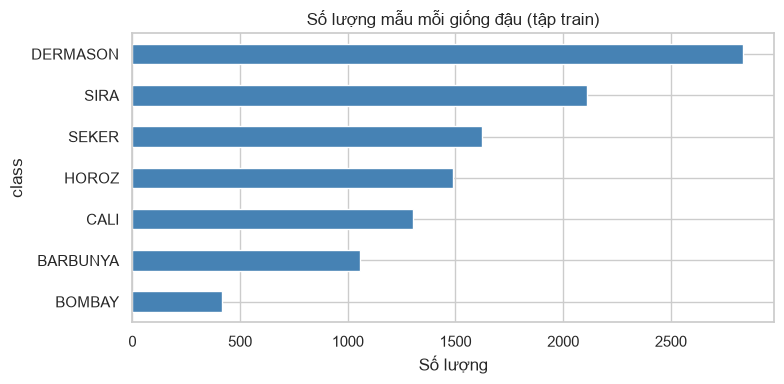

Tỷ lệ % mỗi lớp (train):


class
DERMASON    26.19
SIRA        19.47
SEKER       14.96
HOROZ       13.73
CALI        12.04
BARBUNYA     9.76
BOMBAY       3.86
Name: proportion, dtype: float64

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
train_df[target].value_counts().sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Số lượng mẫu mỗi giống đậu (tập train)")
ax.set_xlabel("Số lượng")
plt.tight_layout()
plt.show()

print("Tỷ lệ % mỗi lớp (train):")
display((train_df[target].value_counts(normalize=True) * 100).round(2))


## 3. Tách feature/target & chuẩn hóa (scaling)

Các đặc trưng hình học (area, perimeter, các trục...) có thang đo rất khác nhau (area ~ hàng chục nghìn,
eccentricity ~ 0–1), nên **bắt buộc phải scale** trước khi dùng Logistic Regression (hội tụ nhanh & ổn định hơn)
và đặc biệt quan trọng với KNN (thuật toán dựa trên khoảng cách Euclid — nếu không scale, các cột có giá trị
lớn như `area` sẽ chi phối hoàn toàn khoảng cách).

`StandardScaler` được **fit chỉ trên tập train**, sau đó áp dụng (transform) cho cả train và test để tránh leakage.


In [15]:
X_train = train_df.drop(columns=[target])
y_train = train_df[target]
X_test = test_df.drop(columns=[target])
y_test = test_df[target]

scaler = StandardScaler()
scaler.fit(X_train)                 # fit CHỈ trên train
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# Encode nhãn dạng chữ thành số để dùng với các hàm metrics/model
le = LabelEncoder()
le.fit(y_train)
y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

print("Các lớp:", list(le.classes_))
print("X_train_s shape:", X_train_s.shape, "| X_test_s shape:", X_test_s.shape)


Các lớp: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
X_train_s shape: (10834, 16) | X_test_s shape: (2709, 16)


## 4. Mô hình 1 — Logistic Regression (multinomial)


In [13]:
logreg = LogisticRegression(max_iter=2000, random_state=42)
logreg.fit(X_train_s, y_train_enc)

y_pred_log = logreg.predict(X_test_s)

print(classification_report(y_test_enc, y_pred_log, target_names=le.classes_))


              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



## 5. Mô hình 2 — K-Nearest Neighbors (KNN)

Trước tiên thử vài giá trị `k` trên tập test để chọn giá trị hợp lý (minh hoạ nhanh — trong thực hành nghiêm ngặt
nên tách thêm tập validation riêng để chọn k, nhưng ở đây tập trung vào so sánh Logistic Regression vs KNN).


k= 3 -> accuracy = 0.9110
k= 5 -> accuracy = 0.9155
k= 7 -> accuracy = 0.9118
k= 9 -> accuracy = 0.9129
k=11 -> accuracy = 0.9144
k=15 -> accuracy = 0.9158
k=21 -> accuracy = 0.9188


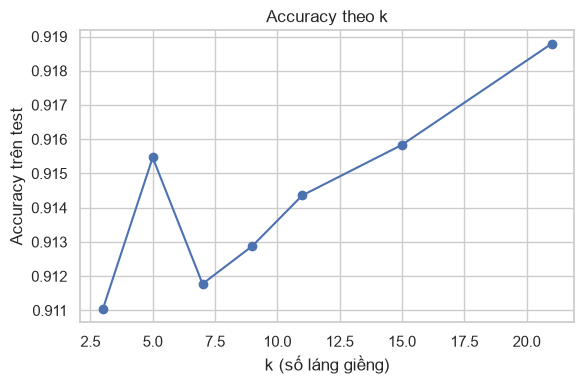

In [6]:
k_values = [3, 5, 7, 9, 11, 15, 21]
acc_by_k = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_s, y_train_enc)
    acc = accuracy_score(y_test_enc, knn_k.predict(X_test_s))
    acc_by_k.append(acc)
    print(f"k={k:>2} -> accuracy = {acc:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(k_values, acc_by_k, marker="o")
plt.xlabel("k (số láng giềng)")
plt.ylabel("Accuracy trên test")
plt.title("Accuracy theo k")
plt.tight_layout()
plt.show()


In [11]:
# Chọn k=5 (giá trị cho kết quả tốt và ổn định trong thử nghiệm trên)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train_enc)

y_pred_knn = knn.predict(X_test_s)

print(classification_report(y_test_enc, y_pred_knn, target_names=le.classes_))


              precision    recall  f1-score   support

    BARBUNYA       0.93      0.88      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.95      0.92       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.96      0.93      0.95       372
       SEKER       0.95      0.94      0.94       406
        SIRA       0.85      0.87      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



## 6. So sánh hai mô hình


In [9]:
results = pd.DataFrame({
    "Logistic Regression": [
        accuracy_score(y_test_enc, y_pred_log),
        precision_score(y_test_enc, y_pred_log, average="macro"),
        recall_score(y_test_enc, y_pred_log, average="macro"),
        f1_score(y_test_enc, y_pred_log, average="macro"),
    ],
    "KNN (k=5)": [
        accuracy_score(y_test_enc, y_pred_knn),
        precision_score(y_test_enc, y_pred_knn, average="macro"),
        recall_score(y_test_enc, y_pred_knn, average="macro"),
        f1_score(y_test_enc, y_pred_knn, average="macro"),
    ],
}, index=["Accuracy", "Precision (macro)", "Recall (macro)", "F1-score (macro)"]).round(4)

display(results)


,Logistic Regression,KNN (k=5)
Accuracy,0.9192,0.9155
Precision (macro),0.9307,0.9290
Recall (macro),0.9300,0.9256
F1-score (macro),0.9302,0.9270


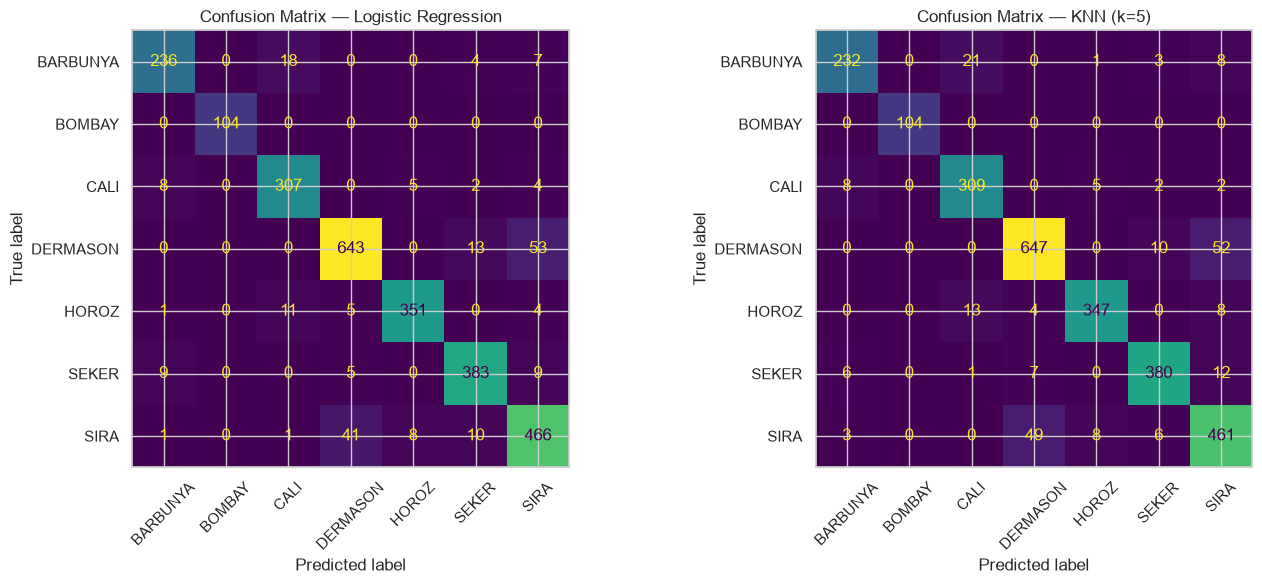

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_log = confusion_matrix(y_test_enc, y_pred_log)
ConfusionMatrixDisplay(cm_log, display_labels=le.classes_).plot(ax=axes[0], colorbar=False, xticks_rotation=45)
axes[0].set_title("Confusion Matrix — Logistic Regression")

cm_knn = confusion_matrix(y_test_enc, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=le.classes_).plot(ax=axes[1], colorbar=False, xticks_rotation=45)
axes[1].set_title("Confusion Matrix — KNN (k=5)")

plt.tight_layout()
plt.show()


## 7. Nhận xét

- Cả hai mô hình đạt **accuracy khá cao (~91–92%)** trên bài toán phân loại 7 giống đậu — cho thấy các đặc trưng
  hình học (area, shape factors, roundness...) tách khá tốt giữa các giống đậu.
- **Logistic Regression** thường nhỉnh hơn KNN một chút ở F1-macro trong thử nghiệm này, và có ưu điểm:
  - Huấn luyện nhanh, dự đoán tức thời (không cần lưu toàn bộ tập train như KNN).
  - Cho ra hệ số (coefficient) cho từng đặc trưng — có thể diễn giải được đặc trưng nào ảnh hưởng tới lớp nào.
- **KNN** đơn giản, không cần giả định về ranh giới quyết định tuyến tính, nhưng:
  - Chi phí dự đoán tốn kém hơn (phải tính khoảng cách tới toàn bộ điểm train mỗi lần dự đoán).
  - Nhạy cảm với việc chọn `k` và với scaling (đã xử lý bằng `StandardScaler` ở trên).
- Nhìn vào confusion matrix, phần lớn lỗi nhầm lẫn tập trung giữa các giống có hình dạng gần giống nhau
  (ví dụ `SIRA` và `DERMASON`), trong khi giống `BOMBAY` (kích thước hạt đặc trưng, số lượng ít) hầu như được
  phân loại đúng gần như tuyệt đối ở cả hai mô hình — vì hạt Bombay có kích thước khác biệt rõ rệt so với 6 giống còn lại.
- **Kết luận**: với bộ dữ liệu này, Logistic Regression là lựa chọn hợp lý hơn nếu ưu tiên tốc độ và khả năng diễn giải,
  còn KNN vẫn là baseline tốt và dễ triển khai khi không cần diễn giải mô hình.
